Import all relevant modules.

In [553]:
import cv2
import os

import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import os

from moviepy.editor import VideoFileClip
from IPython.display import HTML
from random import choice
from scipy.ndimage.measurements import label
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
%matplotlib inline

Let's see what the given test images look like.

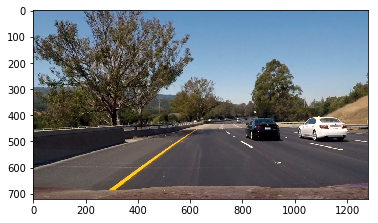

In [4]:
test = plt.imread("test_images/test6.jpg")
plt.imshow(test)

Now let us see an image of a vehicle...

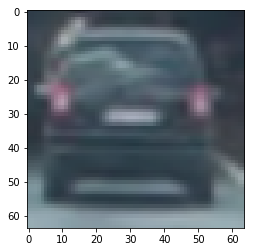

In [6]:
vehicle = plt.imread("datasets/vehicles/GTI_MiddleClose/image0038.png")
plt.imshow(vehicle)

... and an image of a non-vehicle.

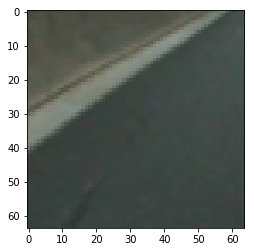

In [8]:
nonvehicle = plt.imread("datasets/non-vehicles/GTI/image2709.png")
plt.imshow(nonvehicle)

Before we train an SVM classifier, we need to write some code to extract HOG features from images.

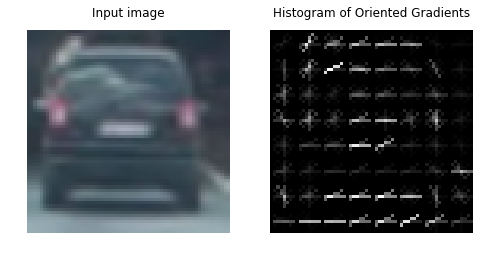

In [429]:
gray = cv2.cvtColor(vehicle, cv2.COLOR_BGR2GRAY)

fd, hog_image = hog(gray, orientations=6, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), visualise=True, block_norm='L2-Hys')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(vehicle, cmap=plt.cm.gray)
ax1.set_title('Input image')
ax1.set_adjustable('box-forced')

ax2.axis('off')
ax2.imshow(hog_image, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
ax1.set_adjustable('box-forced')
plt.show()

In [114]:
def ImageToUnnormalizedFeatures(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_image = hog(
        gray,
        orientations=6,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return hog_image

def FileToUnnormalizedFeatures(filename):
    img = plt.imread(filename)
    return ImageToUnnormalizedFeatures(img)

We now need to list all files containing vehicle- and non-vehicle-images.

In [75]:
def ListRecursivelyWithExtension(topdir, extension):
    out = []
    for dirpath, dirnames, files in os.walk(topdir):
        for name in files:
            if name.lower().endswith(extension):
                out.append(os.path.join(dirpath, name))
    return out

In [78]:
vehicle_imgs = ListRecursivelyWithExtension('./datasets/vehicles', '.png')

In [80]:
non_vehicle_imgs = ListRecursivelyWithExtension('./datasets/non-vehicles', '.png')

We can now create our datasets (first, pre-normalization).

In [86]:
X1 = [FileToUnnormalizedFeatures(filename) for filename in vehicle_imgs]
X2 = [FileToUnnormalizedFeatures(filename) for filename in non_vehicle_imgs]

In [87]:
X = np.concatenate((X1, X2))

In [88]:
y1 = np.ones(len(X1))
y2 = np.zeros(len(X2))
y = np.concatenate((y1, y2))

Before splitting our dataset, we need to normalize it so that all features have mean 0 and variance 1.

In [97]:
X_scaler = StandardScaler().fit(X)
scaled_X = X_scaler.transform(X)

Before fitting the SVM, we split the data into training and validation sets.

In [100]:
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size=0.1)

We can now train our SVM model.

In [419]:
# classifier = SVC(probability=True)
# classifier = LinearSVC()
# classifier = RandomForestClassifier(criterion='entropy')
classifier = GradientBoostingClassifier()
classifier.fit(X_train, y_train)

GradientBoostingClassifier(criterion='friedman_mse', init=None,
              learning_rate=0.1, loss='deviance', max_depth=3,
              max_features=None, max_leaf_nodes=None,
              min_impurity_decrease=0.0, min_impurity_split=None,
              min_samples_leaf=1, min_samples_split=2,
              min_weight_fraction_leaf=0.0, n_estimators=100,
              presort='auto', random_state=None, subsample=1.0, verbose=0,
              warm_start=False)

We now evaluate the model in our validation set.

In [420]:
print(classifier.score(X_test, y_test))
print(classifier.score(X_train, y_train))

0.963963963964
0.977852852853


At this point, we need to implement a sliding-window algorithm to try and figure out where the cars in each image are (in case there are any); this is necessary since we trained our algorithm on an exact crop of cars (in the case of positively-labeled images).

We first display a test video to get some intuition about box sizes.

In [111]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format('test_video.mp4'))

In [507]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format('project_video.mp4'))

We also show a randomly chosen test image.

In [127]:
test_images = ListRecursivelyWithExtension('./test_images', '.jpg')

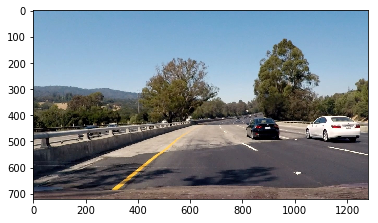

In [505]:
random = plt.imread(choice(test_images))
plt.imshow(random)

We must not forget that, on new images, one must apply normalization before calling the classifier.
As such, we create a wrapper applies the correct preprocessing.

In [479]:
def Preprocess(img):
    x = ImageToUnnormalizedFeatures(img)
    return X_scaler.transform(np.hstack((x)).reshape(1, -1))[0]

We use a simple multi-scale sliding window approach. We discard the upper half of the image.

In [187]:
dims = (720, 1280, 3)

def MultiScaleWindows():
    boxes = []
    horizon_y = 400
    min_size = 50
    max_size = 250
    current_height = horizon_y + min_size//2
    current_size = min_size
    max_y = dims[0] - max_size//2
    while (current_height + current_size//2 <= max_y):
        # iterate laterally
        current_width = 3 * current_size//2
        max_x = dims[1] - current_size//2
        while (current_width + current_size//2 <= max_x):
            boxes.append(
                (
                    (current_width - current_size//2, current_height - current_size//2),
                    (current_width + current_size//2, current_height + current_size//2)
                )
            )
            current_width += current_size//2 # go right
        current_height += current_size//3 # go down
        # increase box size
        current_size = ((current_height - horizon_y) * max_size + (max_y - current_height) * min_size)//(max_y - horizon_y)
    return boxes

In [190]:
def DrawBoxes(img, bboxes, color=(0, 0, 255), thick=6):
    imcopy = np.copy(img)
    for bbox in bboxes:
        cv2.rectangle(imcopy, bbox[0], bbox[1], color, thick)
    return imcopy

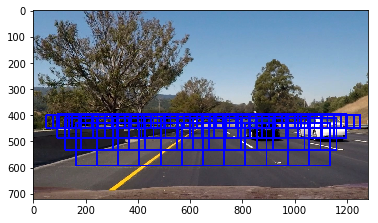

In [191]:
plt.imshow(DrawBoxes(random, MultiScaleWindows()))

Now we want to iterate over the boxes, and apply our classifier to each of them to see which ones contain cars.

In [474]:
def HasCar(img, box):
    cropped = cv2.resize(
        img[box[0][1]:box[1][1], box[0][0]:box[1][0]],
        (64, 64),
        interpolation=cv2.INTER_AREA
    )
    # cropped has values in [0, 255],
    # but in the original dataset the values are in [0, 1].
    converted = cropped.astype(np.float32)/255
    preprocessed = Preprocess(converted)
    classification = classifier.predict([preprocessed])[0]
    return classification == 1

def NaiveVehicleDetection(img, boxes, color=(0, 0, 255), thick=6):
    imcopy = np.copy(img)
    for box in boxes:
        if HasCar(img, box):
            cv2.rectangle(imcopy, box[0], box[1], color, thick)
    return imcopy

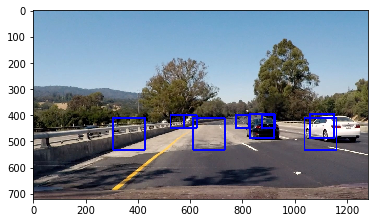

In [519]:
plt.imshow(NaiveVehicleDetection(random, MultiScaleWindows()))

Since we will ultimately use a heatmap to filter out false positives and merge duplicates, my impression is that using multi-scale windows is not necessary. Let us also create a simpler window-generation algorithm.
Also, since we are driving in the left lane in the test video, we will restrict ourselves to the right side of the image.

In [598]:
def UniScaleWindows():
    boxes = []
    horizon_y = 400
    box_size = 100
    current_height = horizon_y + box_size//2
    max_y = dims[0] - box_size
    while (current_height <= max_y):
        current_width = dims[1]//2 + box_size//2
        max_x = dims[1] - box_size//2
        while (current_width <= max_x):
            boxes.append(
                (
                    (current_width - box_size//2, current_height - box_size//2),
                    (current_width + box_size//2, current_height + box_size//2)
                )
            )
            current_width += box_size//6 # go right
        current_height += box_size//6 # go down
    return boxes

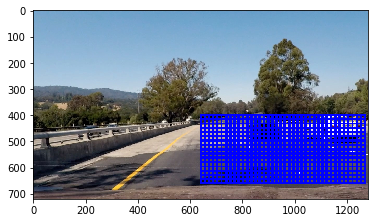

In [599]:
plt.imshow(DrawBoxes(random, UniScaleWindows()))

Let's see what the training/test images look like.

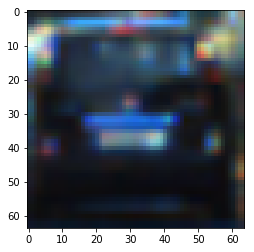

In [485]:
plt.imshow(plt.imread(choice(ListRecursivelyWithExtension('datasets/vehicles', '.png'))))

Let's write a method for generating a heatmap.

In [600]:
def Heatmap(img, boxes, threshold):
    heatmap = np.zeros_like(img[:,:,0]).astype(np.float)
    for box in boxes:
        heatmap[box[0][1]:box[1][1], box[0][0]:box[1][0]] += 1
    heatmap[heatmap <= threshold] = 0
    return heatmap

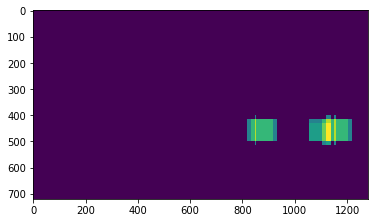

In [601]:
positives = [box for box in UniScaleWindows() if HasCar(random, box)]
heatmap = Heatmap(random, positives, 3)
plt.imshow(heatmap)

2 cars found


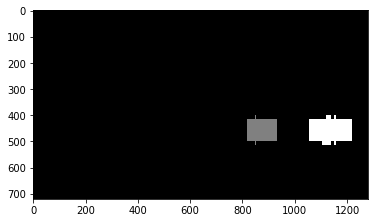

In [584]:
labels = label(heatmap)
print(labels[1], 'cars found')
plt.imshow(labels[0], cmap='gray')

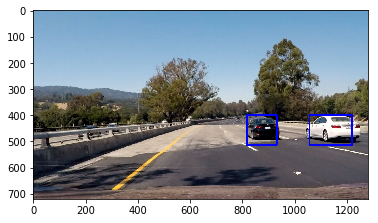

In [602]:
def GetLabelBoxes(img, labels):
    boxes = []
    for car_number in range(1, labels[1]+1):
        nonzero = (labels[0] == car_number).nonzero()
        nonzeroy = np.array(nonzero[0])
        nonzerox = np.array(nonzero[1])
        box = ((np.min(nonzerox), np.min(nonzeroy)), (np.max(nonzerox), np.max(nonzeroy)))
        if (box[1][0] - box[0][0] >= 50 and box[1][1] - box[0][1] >= 50):
            boxes.append(box)
    return boxes

def DrawBetterBoxes(img, labels):
    out = np.copy(img)
    # Iterate through all detected cars
    for bbox in GetLabelBoxes(img, labels):
        cv2.rectangle(out, bbox[0], bbox[1], (0,0,255), 6)
    # Return the image
    return out

plt.imshow(DrawBetterBoxes(random, labels))

Let's write the pipeline for the video annotation.

In [586]:
source = VideoFileClip("test_video.mp4")#.subclip(20, 25)
target = "test_video_out.mp4"

boxes = UniScaleWindows()
def closure(img):
    return NaiveVehicleDetection(img, boxes)

annotated = source.fl_image(closure)
%time annotated.write_videofile(target, audio=False)

[MoviePy] >>>> Building video test_video_out.mp4
[MoviePy] Writing video test_video_out.mp4


 97%|█████████▋| 38/39 [03:04<00:04,  4.80s/it]


[MoviePy] Done.
[MoviePy] >>>> Video ready: test_video_out.mp4 

CPU times: user 3min 3s, sys: 381 ms, total: 3min 4s
Wall time: 3min 4s


In [589]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format('test_video_out.mp4'))

Next, we need to use the heatmap to create the relevant boxes.

In [594]:
boxes = UniScaleWindows()

def BetterVehicleDetection(img):
    positives = [box for box in boxes if HasCar(img, box)]
    heatmap = Heatmap(img, positives, 2)
    labels = label(heatmap)
    return DrawBetterBoxes(img, labels)

In [595]:
source = VideoFileClip("test_video.mp4")#.subclip(20, 25)
target = "test_video_out_better.mp4"

boxes = UniScaleWindows()

annotated = source.fl_image(BetterVehicleDetection)
%time annotated.write_videofile(target, audio=False)

[MoviePy] >>>> Building video test_video_out_better.mp4
[MoviePy] Writing video test_video_out_better.mp4


 97%|█████████▋| 38/39 [03:09<00:04,  4.87s/it]


[MoviePy] Done.
[MoviePy] >>>> Video ready: test_video_out_better.mp4 

CPU times: user 3min 8s, sys: 621 ms, total: 3min 8s
Wall time: 3min 9s


In [596]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format('test_video_out_better.mp4'))

Let's run the pipeline on the project video.

In [604]:
source = VideoFileClip("project_video.mp4")#.subclip(20, 25)
target = "project_video_out_better.mp4"

boxes = UniScaleWindows()

annotated = source.fl_image(BetterVehicleDetection)
%time annotated.write_videofile(target, audio=False)

[MoviePy] >>>> Building video project_video_out_better.mp4
[MoviePy] Writing video project_video_out_better.mp4


100%|█████████▉| 1260/1261 [46:29<00:02,  2.22s/it]


[MoviePy] Done.
[MoviePy] >>>> Video ready: project_video_out_better.mp4 

CPU times: user 46min 19s, sys: 7.71 s, total: 46min 27s
Wall time: 46min 29s


In [605]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format('project_video_out_better.mp4'))